In [57]:
# https://gemini.google.com/app/382b654dbefb22e8

import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

In [58]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

In [59]:
# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import align_comp_to_port, evaluate_bbox

In [ ]:

# Base parameters for PMOS and NMOS
stdp_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation(),
        "routing_metal": "met2",
        "dummy_devices": True,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}
nmos_kwargs = {
    "with_tie": False,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True,
}

pmos_kwargs = {
    "with_tie": False,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True,
}

In [ ]:


def stdp_unit(pdk, config):
    stdp_comp = Component(name="stdp_lvs")
    rules = config["layout_rules"]
    spacing = rules["spacing"]
    tie_layers = rules["tie_layers"]
    sd_rmult = rules["sd_rmult"]

    # =========================================================================
    # 1. INSTANTIATE ALL DEVICES MATCHING SPICE NETLIST
    # =========================================================================

    # --- PMOS TRANSISTORS ---
    # XM1: W=0.22u, L=0.28u
    xm1 = pmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
    # XM2: W=0.22u, L=0.28u
    xm2 = pmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
    # XM7: W=0.22u, L=0.28u
    xm7 = pmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
    # XM8: W=0.22u, L=0.28u
    xm8 = pmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
    # XM17: W=0.3u, L=4.6u
    xm17 = pmos(pdk, width=0.5, length=4.6, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
    # XM16: W=10.2u, L=2.8u
    xm16 = pmos(pdk, width=10.2, length=2.8, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

    # --- NMOS TRANSISTORS ---
    # XM3: W=0.22u, L=0.28u
    xm3 = nmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
    # XM4: W=0.22u, L=0.28u
    xm4 = nmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
    # XM9: W=0.22u, L=0.28u
    xm9 = nmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
    # XM12: W=0.22u, L=0.28u
    xm12 = nmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
    # XMCM_1: W=0.61u, L=2.8u
    xmcm_1 = nmos(pdk, width=0.61, length=2.8, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)

    # --- LONG-CHANNEL BIAS CHAIN (XMCM_5 to XMCM_9): W=0.5u, L=10u ---
    xmcm_chain = [
        nmos(pdk, width=0.5, length=10.0, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
        for _ in range(5)
    ]

    # --- MIM CAPACITORS ---
    # Cpot: 5x5um, m=2 (2 rows, 1 col)
    cpot = mimcap_array(pdk, size=(5, 5), rows=2, columns=1)
    # Cdep: 5x5um, m=2 (2 rows, 1 col)
    cdep = mimcap_array(pdk, size=(5, 5), rows=2, columns=1)
    # Cw: 5x5um, m=10 (2 rows, 5 cols)
    cw = mimcap_array(pdk, size=(5, 5), rows=2, columns=5)

    # =========================================================================
    # 2. PLACEMENT & FLOORPLANNING
    # =========================================================================

    # Add components to subcircuit
    #top row
    xm1_ref = stdp_comp << xm1
    xm2_ref = stdp_comp << xm2
    xm7_ref = stdp_comp << xm7
    xm8_ref = stdp_comp << xm8
    xm17_ref = stdp_comp << xm17
    xm16_ref = stdp_comp << xm16

    xm1_ref.name = "xm1" 
    xm2_ref.name = "xm2" 
    xm7_ref.name = "xm7" 
    xm8_ref.name = "xm8" 
    xm17_ref.name = "xm17" 
    xm16_ref.name = "xm16" 
    
    # second row
    xm3_ref = stdp_comp << xm3
    xm4_ref = stdp_comp << xm4
    xm9_ref = stdp_comp << xm9
    xm12_ref = stdp_comp << xm12
    xm3_ref.name = "xm3"
    xm4_ref.name = "xm4"
    xm9_ref.name = "xm9"
    xm12_ref.name = "xm12"
    
    xmcm_1_ref = stdp_comp << xmcm_1
    chain_refs = [stdp_comp << dev for dev in xmcm_chain]

    cpot_ref = stdp_comp << cpot
    cdep_ref = stdp_comp << cdep
    cw_ref = stdp_comp << cw
    cpot_ref.name = "cpot" 
    cdep_ref.name = "cdep" 
    cw_ref.name = "cw" 

    # --- TOP ROW: PMOS Array ---

    xm2_xy = evaluate_bbox(xm2)
    xm7_xy = evaluate_bbox(xm8)
    xm8_xy = evaluate_bbox(xm8)
    xm17_xy = evaluate_bbox(xm17)
    xm16_xy = evaluate_bbox(xm16)
    cpot_xy = evaluate_bbox(cpot)
    xm1_ref.move((0, 25))
    xm2_ref.move((xm1_ref.xmax + xm2_xy[0]/2 + spacing, 25))
    xm7_ref.move((xm2_ref.xmax + xm7_xy[0]/2 + spacing, 25))
    xm8_ref.move((xm7_ref.xmax + xm8_xy[0]/2 + spacing, 25))
    xm17_ref.move((xm8_ref.xmax + xm17_xy[0]/2 + spacing, 25))
    xm16_ref.move((xm17_ref.xmax + xm16_xy[0]/2 + spacing, 25))
    cpot_ref.move((xm16_ref.xmax + cpot_xy[0]/2 + spacing * 2, 25))

    # --- MIDDLE ROW: Standard NMOS Array ---
    xm3_xy = evaluate_bbox(xm3)
    xm4_xy = evaluate_bbox(xm4)
    xm9_xy = evaluate_bbox(xm9)
    xm12_xy = evaluate_bbox(xm12)
    xmcm_1_xy = evaluate_bbox(xmcm_1)
    cdep_xy = evaluate_bbox(cdep)

    xm3_ref.move((0, 10))
    xm4_ref.move((xm3_ref.xmax + xm4_xy[0]/2 + spacing, 10))
    xm9_ref.move((xm4_ref.xmax + xm9_xy[0]/2 +spacing, 10))
    xm12_ref.move((xm9_ref.xmax + xm12_xy[0]/2 + spacing, 10))
    xmcm_1_ref.move((xm12_ref.xmax + xmcm_1_xy[0]/2 + spacing, 10))
    cdep_ref.move((cpot_ref.xmax + cdep_xy[0]/2 + spacing * 2, 10))

    # --- BOTTOM ROW: Long-Channel Bias Chain (Series connected) ---
    curr_x = 0
    for ref in chain_refs:
        ref.move((curr_x, 0))
        xy_next = evaluate_bbox(ref)
        curr_x = ref.xmax + xy_next[0]/2 +  spacing

    # --- RIGHT SIDE: Main Weight Storage MIM Cap Array (Cw) ---
    cw_xy = evaluate_bbox(cw)
    cw_ref.move((cpot_ref.xmax + cw_xy[0]/2 + spacing * 3, 0))

    # =========================================================================
    # 3. ROUTING CRITICAL NETS
    # =========================================================================

    # # Net1: XM1 Drain/Source to XM2 Source/Drain
    # stdp_comp << c_route(
    #     pdk,
    #     xm1_ref.ports["multiplier_0_source_E"],
    #     xm2_ref.ports["multiplier_0_source_W"],
    #     extension=1.0,
    # )

    # Net1: Routing out of the TOP of both PMOS devices
    stdp_comp << c_route(
        pdk,
        xm1_ref.ports["multiplier_0_source_N"],
        xm2_ref.ports["multiplier_0_source_N"],
        extension=2.0
    )

    # Net2: XM3 Source/Drain to XM4 Drain/Source
    # stdp_comp << c_route(
    #     pdk,
    #     xm3_ref.ports["multiplier_0_source_E"],
    #     xm4_ref.ports["multiplier_0_source_W"],
    #     extension=1.0,
    # )
    # Route out of the TOP (North) of both transistors and loop around
    stdp_comp << c_route(
        pdk,
        xm3_ref.ports["multiplier_0_source_N"],
        xm4_ref.ports["multiplier_0_source_N"],
        extension=2.0  # Distance in um to extend upwards before bending
    )

    # Net5: XM9 to XM12 / XM16
    stdp_comp << straight_route(
        pdk,
        xm9_ref.ports["multiplier_0_drain_N"],
        xm12_ref.ports["multiplier_0_drain_N"],
    )

    # Chain Series Connections (MCM_5 to MCM_9)
    for i in range(len(chain_refs) - 1):
        stdp_comp << straight_route(
            pdk,
            chain_refs[i].ports["multiplier_0_source_E"],
            chain_refs[i + 1].ports["multiplier_0_drain_W"],
        )

    # Print all available port names on the Cdep capacitor component
    # print(cdep_ref.ports)

    # Vdep connection: Cdep to XM4/XM12
    # stdp_comp << L_route(
    #     pdk,
    #     cdep_ref.ports["top_met_N"],
    #     xm12_ref.ports["multiplier_0_gate_S"],
    # )
    stdp_comp << L_route(
        pdk,
        cdep_ref.ports["row0_col0_top_met_W"],
        xm12_ref.ports["multiplier_0_gate_S"],
    )


    # Vpot connection: Cpot to XM8/XM17
    # stdp_comp << L_route(
    #     pdk,
    #     cpot_ref.ports["top_met_S"],
    #     xm17_ref.ports["multiplier_0_drain_E"],
    # )
    stdp_comp << L_route(
        pdk,
        cpot_ref.ports["row1_col0_top_met_S"],
        xm17_ref.ports["multiplier_0_drain_E"],
    )


    return stdp_comp, cdep_ref.ports, cpot_ref.ports



In [62]:
# Instantiate subcircuit
stdp_cell, cdep_top_ports, cpot_top_ports = stdp_unit(gf180, stdp_config)


In [63]:
stdp_cell.show()

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 19 in 'stdp_lvs$10'
  gdspath = component.write_gds(
2026-07-30 22:14:48.670 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "open", "file": "/tmp/gdsfactory/stdp_lvs$10.gds"}


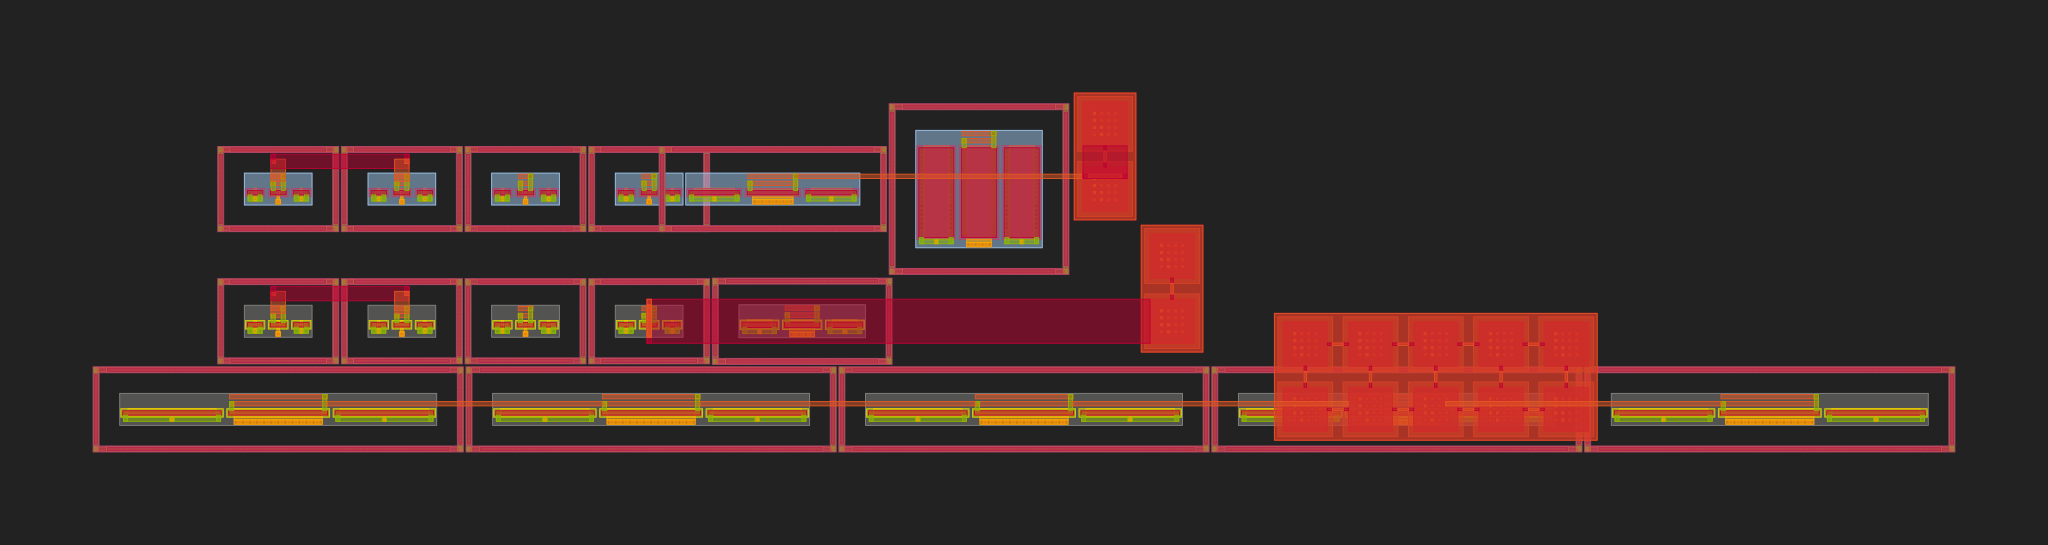

In [64]:
display_component(stdp_cell, scale = 1,path=".")